In [30]:
import xarray as xr
import fsspec
import zarr
import dask.array as da
import numpy as np
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from datetime import datetime, timedelta
from metpy.calc import lat_lon_grid_deltas, vorticity, smooth_gaussian
from metpy.units import units
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cosine
from scipy.spatial import cKDTree 

In [2]:
allLevelsFile = '../data/sandy2012-windUV_all_levels_from_250_to_850-rechunked.zarr'
subsetLevelsFile = '../data/sandy2012-windUV_250_500_850.zarr'
sandyCoordsFile = "../data/sandy2012-coords.csv"

allLevelsDs = xr.open_zarr(allLevelsFile, consolidated=False)
subsetLevelsDs = xr.open_zarr(subsetLevelsFile, consolidated=False)
sandyCoords = pd.read_csv(sandyCoordsFile)

In [3]:
sandyCoords["datetime"] = pd.to_datetime(sandyCoords["datetime"])
sandyCoords = sandyCoords.sort_values("datetime").reset_index(drop=True)

sandyCoords["lat"] = sandyCoords["lat"].astype(float)
sandyCoords["lon"] = sandyCoords["lon"].astype(float)
sandyCoords


,datetime,lat,lon
0,2012-10-22 00:00:00,13.9,-77.8
1,2012-10-22 06:00:00,13.5,-78.2
2,2012-10-22 12:00:00,13.1,-78.6
3,2012-10-22 18:00:00,12.7,-78.7
4,2012-10-23 00:00:00,12.6,-78.4
5,2012-10-23 06:00:00,12.9,-78.1
6,2012-10-23 12:00:00,13.4,-77.9
7,2012-10-23 18:00:00,14.0,-77.6
8,2012-10-24 00:00:00,14.7,-77.3
9,2012-10-24 06:00:00,15.6,-77.1


In [4]:
def get_uv_at_level_time(ds, level, time):
    """
    Select u, v, lats, lons from an xarray Dataset at a given pressure level and time.

    Assumptions:
      - u and v are always shaped (nlat, nlon), e.g. (721, 1440)
      - latitude corresponds to axis 0
      - longitude corresponds to axis 1

    Normalization:
      - If lats are decreasing, flip lats and flip u/v along axis 0.
      - If lons are in [0, 360), convert to [-180, 180) and reorder u/v along axis 1.
    """
    sel = ds.sel(time=time, level=level)

    u = sel["u"].values
    v = sel["v"].values
    lats = sel["latitude"].values
    lons = sel["longitude"].values

    # ---- Latitude: ensure increasing (-90 -> 90) ----
    if len(lats) > 1 and lats[0] > lats[-1]:
        lats = lats[::-1]
        u = u[::-1, :]
        v = v[::-1, :]

    # ---- Longitude: ensure [-180, 180) instead of [0, 360) ----
    # Heuristic: if any lon > 180, treat as 0..360 convention.
    if len(lons) > 0 and np.nanmax(lons) > 180:
        lons_wrapped = ((lons + 180) % 360) - 180   # -> [-180, 180)
        order = np.argsort(lons_wrapped)

        lons = lons_wrapped[order]
        u = u[:, order]
        v = v[:, order]

    return u, v, lats, lons

u, v, lats, lons = get_uv_at_level_time(
    subsetLevelsDs,
    level=850,
    time="2012-10-29T00:00:00",
)

In [72]:
def interp_storm_latlon(storm_df, time):
    t = pd.to_datetime(time)

    dt = storm_df["datetime"].values

    if t.to_datetime64() < dt[0] or t.to_datetime64() > dt[-1]:
        return None

    exact = storm_df.loc[storm_df["datetime"] == t]
    if len(exact) > 0:
        return float(exact["lat"].iloc[0]), float(exact["lon"].iloc[0])

    i = np.searchsorted(dt, t.to_datetime64(), side="right")
    i0, i1 = i - 1, i

    t0 = storm_df["datetime"].iloc[i0]
    t1 = storm_df["datetime"].iloc[i1]

    frac = (t - t0) / (t1 - t0)

    lat0, lat1 = storm_df["lat"].iloc[i0], storm_df["lat"].iloc[i1]
    lon0, lon1 = storm_df["lon"].iloc[i0], storm_df["lon"].iloc[i1]

    lat = float(lat0 + frac * (lat1 - lat0))
    lon = float(lon0 + frac * (lon1 - lon0))

    return lat, lon

def plot_wind_quiver_single_uv(
    u,
    v,
    lats,
    lons,
    *,
    time=None,                          # only used for storm dot interpolation
    stride: int = 10,
    extent=None,
    max_speed_for_black=None,
    ax=None,
    title: str | None = None,
    storm_df: pd.DataFrame | None = None,
    show_storm_dot: bool = True,
    storm_dot_size: float = 22,
):
    """
    Core renderer: given u/v + lat/lon arrays for ONE time, plot quiver + coastline +
    optional storm dot at `time` (and +6h dot).
    """
    Lon, Lat = np.meshgrid(lons, lats)

    Lon_s = Lon[::stride, ::stride]
    Lat_s = Lat[::stride, ::stride]
    u_s   = u[::stride, ::stride]
    v_s   = v[::stride, ::stride]

    speed = np.sqrt(u_s**2 + v_s**2)

    if max_speed_for_black is None:
        max_speed_for_black = float(np.nanpercentile(speed, 95)) if np.isfinite(speed).any() else 1.0
        if max_speed_for_black <= 0:
            max_speed_for_black = 1.0

    if ax is None:
        fig = plt.figure(figsize=(6, 4))
        ax = plt.axes(projection=ccrs.PlateCarree())
    else:
        fig = None

    ax.set_facecolor("white")

    if extent is not None:
        lon_min, lon_max, lat_min, lat_max = extent
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

    ax.quiver(
        Lon_s, Lat_s, u_s, v_s, speed,
        transform=ccrs.PlateCarree(),
        cmap="Greys",
        clim=(0.0, max_speed_for_black),
        scale=1500,
        width=0.0012,
        pivot="middle",
    )

    # storm dots (needs time)
    if show_storm_dot and storm_df is not None and time is not None:
        pt = interp_storm_latlon(storm_df, time)
        if pt is not None:
            lat_pt, lon_pt = pt
            ax.scatter(
                [lon_pt], [lat_pt],
                transform=ccrs.PlateCarree(),
                s=storm_dot_size,
                c="red",
                edgecolors="none",
                zorder=10,
            )

            t_next = pd.to_datetime(time) + pd.Timedelta(hours=6)
            pt2 = interp_storm_latlon(storm_df, t_next)
            if pt2 is not None:
                lat2, lon2 = pt2
                ax.scatter(
                    [lon2], [lat2],
                    transform=ccrs.PlateCarree(),
                    s=storm_dot_size,
                    c="#ff9999",
                    edgecolors="none",
                    zorder=10,
                )
                ax.plot(
                    [lon_pt, lon2],
                    [lat_pt, lat2],
                    transform=ccrs.PlateCarree(),
                    color="red",
                    linewidth=1.5,
                    zorder=9,
                )

    if title is not None:
        ax.set_title(title)

    return fig, ax


def plot_wind_quiver_single_from_ds(
    ds,
    pressure_hpa: int,
    time,
    *,
    stride: int = 10,
    extent=None,
    max_speed_for_black=None,
    ax=None,
    storm_df: pd.DataFrame | None = None,
    show_storm_dot: bool = True,
    storm_dot_size: float = 22,
):
    """
    Convenience wrapper: select u/v from ds at (time, pressure_hpa), then call core UV plotter.
    """
    sel = ds.sel(level=pressure_hpa).sel(time=time)

    u = sel["u"].values
    v = sel["v"].values
    lats = sel["latitude"].values
    lons = sel["longitude"].values

    return plot_wind_quiver_single_uv(
        u,
        v,
        lats,
        lons,
        time=time,
        stride=stride,
        extent=extent,
        max_speed_for_black=max_speed_for_black,
        ax=ax,
        title=f"{pressure_hpa} hPa",
        storm_df=storm_df,
        show_storm_dot=show_storm_dot,
        storm_dot_size=storm_dot_size,
    )


def plot_wind_quiver_levels_side_by_side(
    ds,
    pressure_levels,
    time,
    *,
    stride: int = 10,
    extent=None,
    # max_speed_for_black=None,
    storm_df: pd.DataFrame | None = None,
    show_storm_dot: bool = True,
    storm_dot_size: float = 22,
):
    n = len(pressure_levels)

    fig = plt.figure(figsize=(5 * n, 5))
    axes = []
    
    QUIVER_MAX_SPEEDS = {
        850: 35,   # m/s — low-level inflow & storm-scale circulation
        500: 45,   # m/s — mid-level steering flow
        250: 70,   # m/s — upper-level outflow & jet stream
    }


    for i, lvl in enumerate(pressure_levels, start=1):
        ax = fig.add_subplot(1, n, i, projection=ccrs.PlateCarree())
        axes.append(ax)
        max_speed = None
        max_speed = QUIVER_MAX_SPEEDS.get(lvl, None)

        plot_wind_quiver_single_from_ds(
            ds,
            lvl,
            time,
            stride=stride,
            extent=extent,
            max_speed_for_black=max_speed,
            ax=ax,
            storm_df=storm_df,
            show_storm_dot=show_storm_dot,
            storm_dot_size=storm_dot_size,
        )

    fig.suptitle(f"Wind Quivers — {time}", y=0.98)
    fig.tight_layout(w_pad=0.2)

    return fig, axes


In [79]:
def mask_lonely_arrows(u_masked, v_masked, lats, lons, radius_km=50.0, min_neighbors=2):
    """
    Mask arrows (set to NaN) that have < min_neighbors OTHER valid arrows within radius_km.
    Uses a KD-tree in ECEF space (great-circle approx via chord distance).
    """

    u2 = np.array(u_masked, copy=True)
    v2 = np.array(v_masked, copy=True)

    # Ensure lats/lons are 2D arrays matching u/v shape
    if np.ndim(lats) == 1 and np.ndim(lons) == 1 and u2.ndim == 2:
        Lon, Lat = np.meshgrid(lons, lats)
    else:
        print('else')
        Lat = np.asarray(lats)
        Lon = np.asarray(lons)

    valid = np.isfinite(u2) & np.isfinite(v2) & np.isfinite(Lat) & np.isfinite(Lon)
    if not np.any(valid):
        print('not valid')
        return u2, v2

    # Flatten valid points
    idx = np.flatnonzero(valid.ravel())
    lat = np.deg2rad(Lat.ravel()[idx])
    lon = np.deg2rad(Lon.ravel()[idx])

    # ECEF coordinates on sphere (meters)
    R = 6_371_000.0
    x = R * np.cos(lat) * np.cos(lon)
    y = R * np.cos(lat) * np.sin(lon)
    z = R * np.sin(lat)
    pts = np.stack([x, y, z], axis=1)

    tree = cKDTree(pts)

    # Convert surface distance to chord distance for KDTree radius query
    d = radius_km * 1000.0
    chord_r = 2.0 * R * np.sin(d / (2.0 * R))

    # Count neighbors within radius (excluding itself)
    neighbors = tree.query_ball_point(pts, r=chord_r)
    counts = np.fromiter((len(n) - 1 for n in neighbors), dtype=np.int32, count=len(neighbors))

    to_drop = counts < int(min_neighbors)
    total = counts.size
    dropped = int(np.count_nonzero(to_drop))
    kept = total - dropped

    print(f"dropping {dropped} / {total} ({(dropped/total)*100:.2f}%) | "
        f"keeping {kept} / {total} ({(kept/total)*100:.2f}%)")
    if np.any(to_drop):
        drop_flat = idx[to_drop]
        np.put(u2, drop_flat, np.nan)
        np.put(v2, drop_flat, np.nan)


    return u2, v2


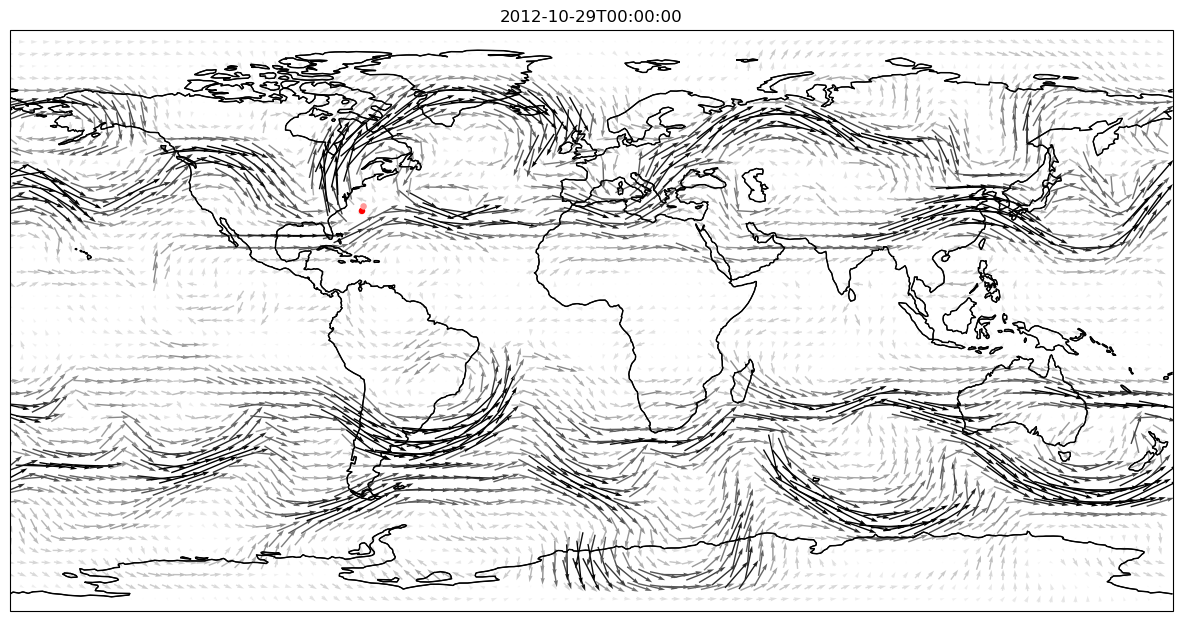

In [91]:
timeStr = "2012-10-29T00:00:00"
level = 250

u, v, lats, lons = get_uv_at_level_time(
    subsetLevelsDs,
    level=level,
    time=timeStr,
)

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-100, -60, 0, 30), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

plot_wind_quiver_single_uv(
    u, v, lats, lons,
    time=timeStr,
    stride=15,
    extent=(-180, 180, -90, 90),
    ax=ax,
    storm_df=sandyCoords,
    title=f"{timeStr}",
)

plt.show()


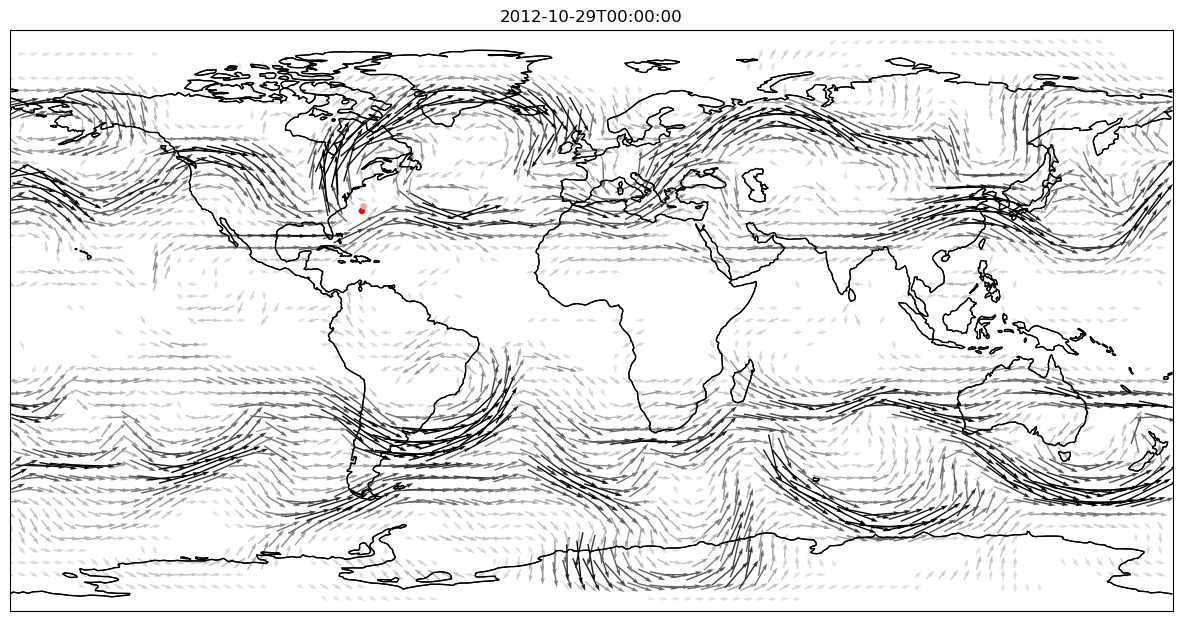

In [92]:
speed = np.hypot(u, v)          # sqrt(u**2 + v**2)
mask = speed < 10.0             # True where “moves less than 10 m/s”

u_masked = np.where(mask, np.nan, u)
v_masked = np.where(mask, np.nan, v)

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-100, -60, 0, 30), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

plot_wind_quiver_single_uv(
    u_masked, v_masked, lats, lons,
    time=timeStr,
    stride=15,
    extent=(-180, 180, -90, 90),
    ax=ax,
    storm_df=sandyCoords,
    title=f"{timeStr}",
)

plt.show()


dropping 173460 / 744625 (23.29%) | keeping 571165 / 744625 (76.71%)


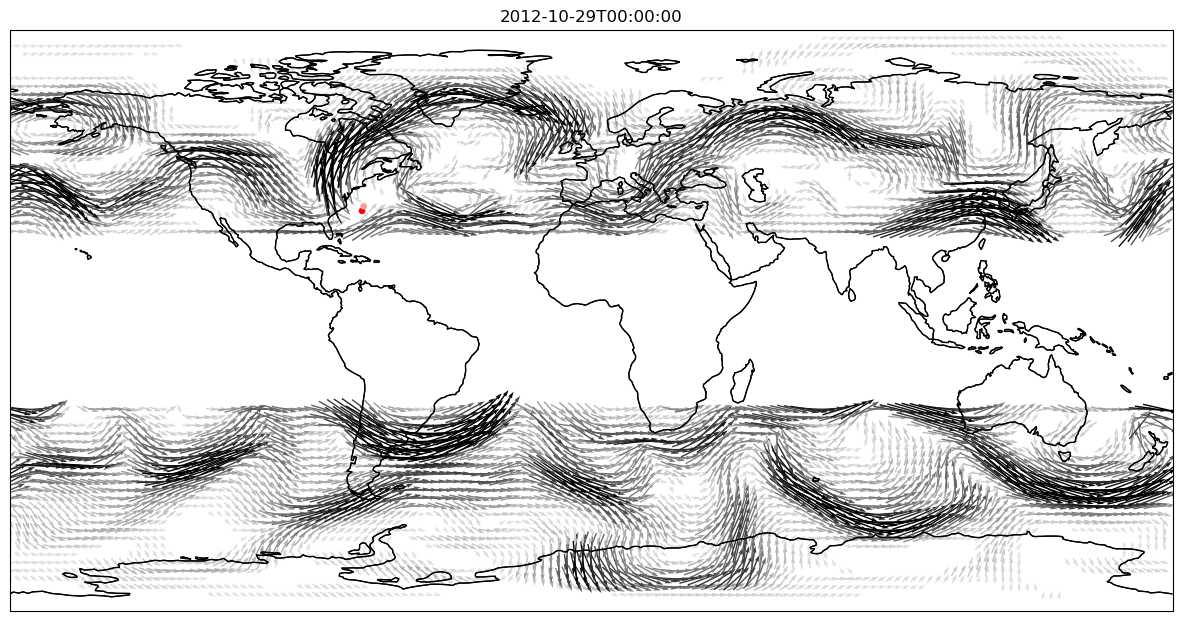

In [96]:
u_masked2, v_masked2 = mask_lonely_arrows(u_masked, v_masked, lats, lons, radius_km=50, min_neighbors=10)

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent((-100, -60, 0, 30), crs=ccrs.PlateCarree())
ax.coastlines(linewidth=1)

plot_wind_quiver_single_uv(
    u_masked2, v_masked2, lats, lons,
    time=timeStr,
    stride=10,
    extent=(-180, 180, -90, 90),
    ax=ax,
    storm_df=sandyCoords,
    title=f"{timeStr}",
)

plt.show()

In [101]:
allLevelsDs.level

<xarray.DataArray 'level' (level: 13)> Size: 104B
array([250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850])
Coordinates:
  * level    (level) int64 104B 250 300 350 400 450 500 ... 650 700 750 800 850